### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/IAT461_LAB02/grades_crpt.csv')
print(df.head())
print(df.shape)
print(df.columns)

      A1    A2    A3    A4     A5     A6    A7  Final_Exam user_id
0    NaN   NaN  30.0  75.0   90.0   65.0  50.6        68.8    U001
1  100.0   NaN   NaN  92.5  100.0  100.0  84.4        50.3    U002
2   75.0  69.6   NaN  86.2  100.0    NaN   NaN        67.8    U003
3   25.0  78.6  40.0   0.0   50.0   30.7   0.0         0.0    U004
4    0.0   NaN   0.0   0.0    NaN    NaN   NaN         0.0    U005
(86, 9)
Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam', 'user_id'], dtype='object')


In [ ]:
print(df.describe())

               A1          A2          A3          A4          A5          A6  \
count   57.000000   61.000000   62.000000   77.000000   61.000000   67.000000   
mean    83.671930   81.096721   68.174194   82.332468   89.645902   74.437313   
std     34.286481   28.556721   42.343621   39.101984   25.510505   31.176535   
min     -4.500000  -30.600000  -70.100000  -21.600000    7.700000  -17.000000   
25%     75.800000   64.300000   50.000000   72.000000   87.000000   60.000000   
50%     87.500000   91.100000   80.000000   87.500000   95.000000   80.000000   
75%     95.800000  100.000000   93.250000   95.000000  100.000000   92.500000   
max    174.600000  148.900000  152.200000  188.200000  173.900000  183.600000   

               A7  Final_Exam  
count   76.000000   86.000000  
mean    78.130263   55.509302  
std     26.412058   18.176777  
min      0.000000    0.000000  
25%     70.300000   45.850000  
50%     80.000000   56.050000  
75%     87.500000   67.725000  
max    150.600

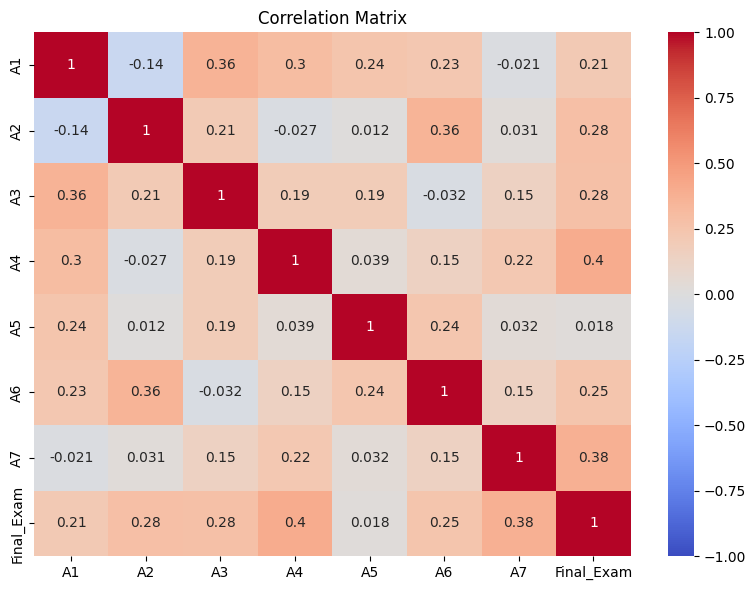

In [ ]:
corr = df[['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64


In [ ]:
# Strategy 1: Fill with mean
df['A4_mean'] = df['A4'].fillna(df['A4'].mean())
df['A7_mean'] = df['A7'].fillna(df['A7'].mean())

# Strategy 2: Fill with median
df['A4_median'] = df['A4'].fillna(df['A4'].median())
df['A7_median'] = df['A7'].fillna(df['A7'].median())

print("A4 missing after mean fill:", df['A4_mean'].isnull().sum())
print("A7 missing after mean fill:", df['A7_mean'].isnull().sum())

A4 missing after mean fill: 0
A7 missing after mean fill: 0


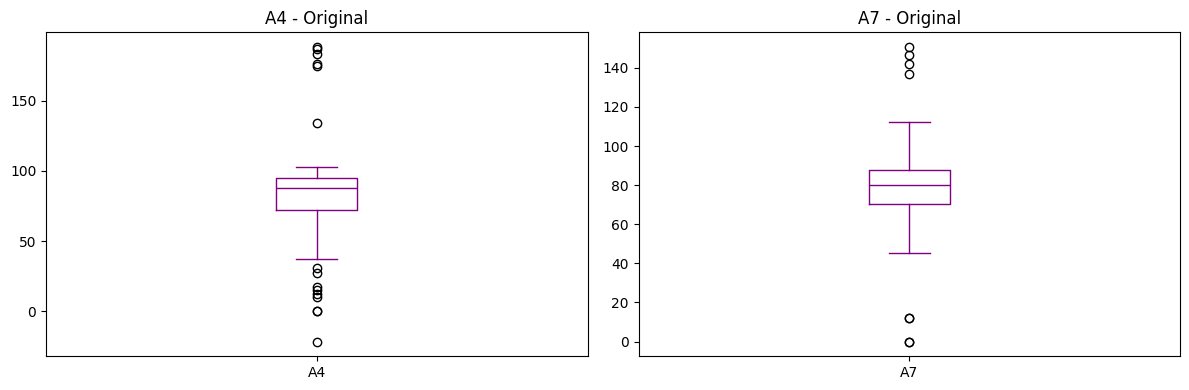

In [ ]:
# Checking outliers with boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['A4'].plot(kind='box', ax=axes[0], color='purple')
axes[0].set_title('A4 - Original')

df['A7'].plot(kind='box', ax=axes[1], color='purple')
axes[1].set_title('A7 - Original')

plt.tight_layout()
plt.show()

In [ ]:
# Strategy 1: Cap outliers at reasonable max
# A4 max should be 105 (100 + 5 bonus)
# A7 max should be 100 (no bonus)
df['A4_capped'] = df['A4'].clip(lower=0, upper=105)
df['A7_capped'] = df['A7'].clip(lower=0, upper=100)

# Strategy 2: Remove negative values
df['A4_cleaned'] = df['A4'].where(df['A4'] >= 0)
df['A7_cleaned'] = df['A7'].where(df['A7'] >= 0)

print("A4 after capping:")
print(df['A4_capped'].describe())

A4 after capping:
count     77.000000
mean      77.251948
std       28.330714
min        0.000000
25%       72.000000
50%       87.500000
75%       95.000000
max      105.000000
Name: A4_capped, dtype: float64


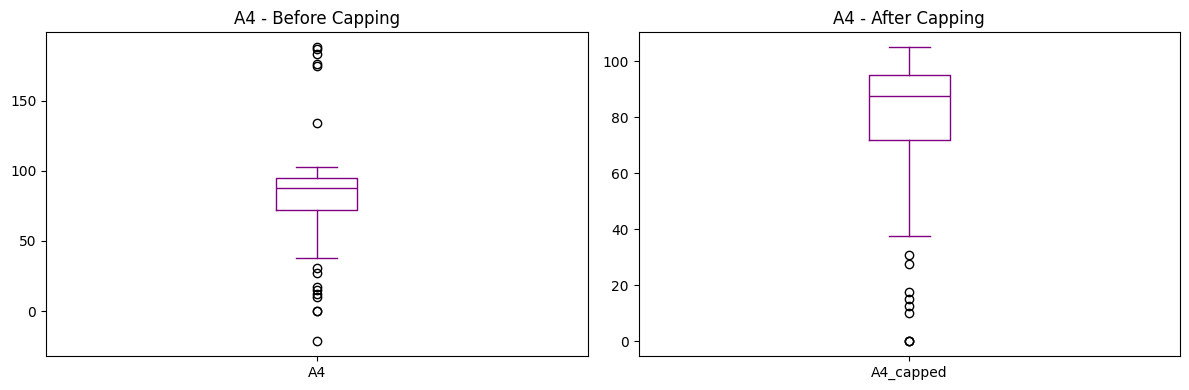

In [ ]:
# Before/after comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['A4'].plot(kind='box', ax=axes[0], color='purple')
axes[0].set_title('A4 - Before Capping')

df['A4_capped'].plot(kind='box', ax=axes[1], color='purple')
axes[1].set_title('A4 - After Capping')

plt.tight_layout()
plt.show()

## Summary

**Dataset:** 86 students, 7 assignments and a final exam.

**Correlation Analysis:**
A4 (0.4) and A7 (0.38) have the strongest correlation with Final_Exam.
These two assignments would be the best predictors of final exam performance.

**Missing Values:**
A1 had the most missing values (29), A4 the least (9).
Used mean and median imputation strategies for A4 and A7.

**Outliers:**
Several assignments had values above 100+ (e.g. A4 max was 188).
Negative values were also found.Outliers were capped at the maximum reasonable value (105 for A4, 100 for A7).
The boxplot comparison shows a clean distribution after capping.